# BL state comparison: base 1D vs base 3D vs nudge 3D

All three runs: no aerosols, zero winds.

| Label | Experiment | RT |
|-------|-----------|----|
| base 1D | no_aerosols_zero_wind | 2stream |
| base 3D | no_aerosols_zero_wind | raytracer |
| nudge 3D | mean_state_nudge/nudge_3600s | raytracer (nudged → 2stream mean state) |

**Goal**: test whether the nudge actually constrained the BL thermodynamic state to the 1D profile,
and characterise what BL differences remain.

In [1]:
import sys
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from cass_analysis import load_stats_ensemble

SCRATCH = "/pscratch/sd/m/mpowell/CASS_LES"
N_REPS  = 4

def rep_dirs(root):
    return [f"{root}/rep_{i:02d}" for i in range(1, N_REPS + 1)]

dirs = {
    "base 1D":  rep_dirs(f"{SCRATCH}/experiments/no_aerosols_zero_wind/2stream"),
    "base 3D":  rep_dirs(f"{SCRATCH}/experiments/no_aerosols_zero_wind/raytracer"),
    "nudge 3D": rep_dirs(f"{SCRATCH}/experiments/mean_state_nudge/nudge_3600s/raytracer"),
}

STYLE = {
    "base 1D":  dict(color="C0", ls="-",  lw=1.8),
    "base 3D":  dict(color="C1", ls="--", lw=1.8),
    "nudge 3D": dict(color="C2", ls=":",  lw=2.2),
}

# ── Standard stats (thl, qt, ql, SEB, cloud scalars, thv_w resolved flux) ────
stats, stds = {}, {}
for label, ds in dirs.items():
    stats[label], stds[label] = load_stats_ensemble(ds)
    print(f"{label}: {stats[label]['t_local'][0]} → {stats[label]['t_local'][-1]}  (nt={len(stats[label]['t_local'])})")

# ── thv_flux (total virtual heat flux at zh, for BL-top detection) ────────────
# NOTE: MicroHH's zi diagnostic locates the max thl gradient which in shallow Cu
# is dominated by the sponge layer near domain top → zi saturates at ~6388 m.
# Do NOT use it. Instead: BL top = height of min(thv_flux) in [500, 3500] m,
# following the flux-jump method in entrainment/entrainment.ipynb.
def _load_thv_flux_ensemble(rep_dirs_list):
    arrs = []
    for d in rep_dirs_list:
        ds = nc.Dataset(str(Path(d) / "cass.default.0000000.nc"))
        arrs.append(np.array(ds.groups["thermo"].variables["thv_flux"][:]))
        ds.close()
    nt_min = min(a.shape[0] for a in arrs)
    return np.stack([a[:nt_min] for a in arrs], axis=0).mean(axis=0)

thv_flux_ens = {label: _load_thv_flux_ensemble(ds) for label, ds in dirs.items()}

# ── BL-top height time series ─────────────────────────────────────────────────
FLUX_ZMIN, FLUX_ZMAX = 500.0, 3500.0
zh = stats["base 1D"]["zh"]

def z_inv_ts(thv_flux_arr):
    mask = (zh >= FLUX_ZMIN) & (zh <= FLUX_ZMAX)
    idx  = np.argmin(thv_flux_arr[:, mask], axis=1)
    return zh[mask][idx]

z_inv = {label: z_inv_ts(thv_flux_ens[label]) for label in dirs}

# ── Analysis window ───────────────────────────────────────────────────────────
T0 = pd.Timestamp("2005-07-24 12:30")
T1 = pd.Timestamp("2005-07-24 17:00")

def window_mask(s):
    t = pd.DatetimeIndex(s["t_local"])
    return (t >= T0) & (t <= T1)

def window_mean_profile(s, key):
    return s[key][window_mask(s)].mean(axis=0)

z = stats["base 1D"]["z"]

print("\nWindow-mean BL-top (min thv_flux):")
for label in dirs:
    m = window_mask(stats[label])
    nt = min(len(m), z_inv[label].shape[0])
    print(f"  {label}: {z_inv[label][:nt][m[:nt]].mean():.0f} m")

base 1D: 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999  (nt=167)
base 3D: 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999  (nt=167)
nudge 3D: 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999  (nt=167)

Window-mean BL-top (min thv_flux):
  base 1D: 1394 m
  base 3D: 1406 m
  nudge 3D: 1401 m


## 1. Mean thermodynamic profiles (11:30–15:30 LST)

If the nudge actually works, nudge 3D thl and qt should track base 1D closely.

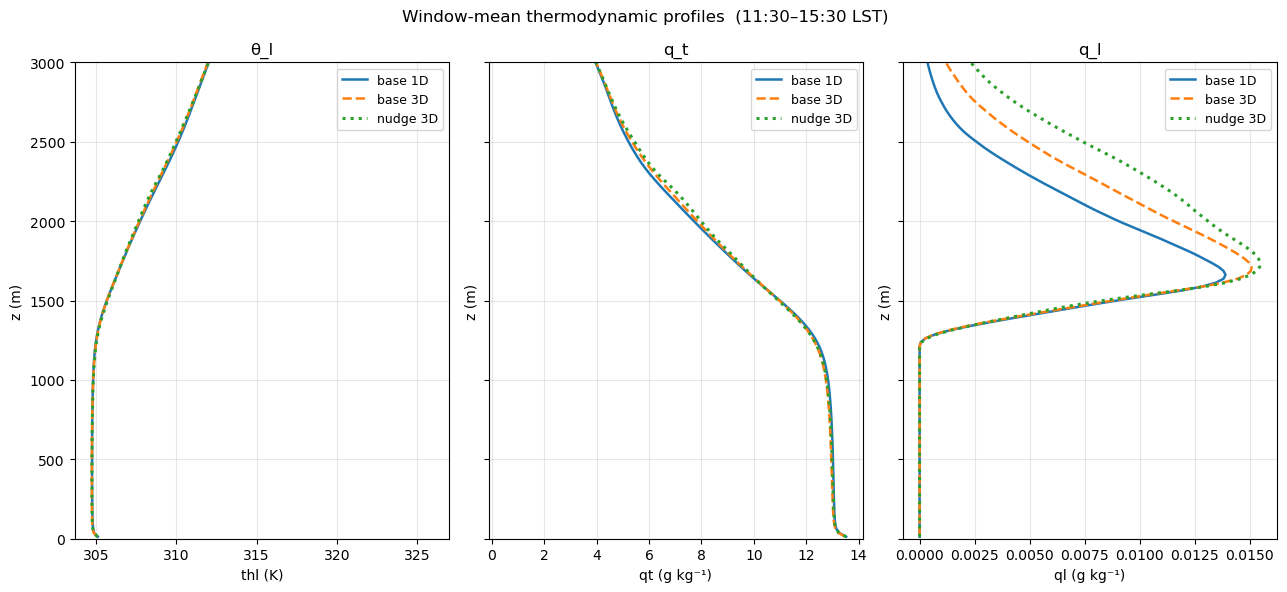

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)

for label, s in stats.items():
    st = STYLE[label]
    thl_mean = window_mean_profile(s, "thl")
    qt_mean  = window_mean_profile(s, "qt") * 1e3   # → g/kg
    ql_mean  = window_mean_profile(s, "ql") * 1e3
    axes[0].plot(thl_mean, z, label=label, **st)
    axes[1].plot(qt_mean,  z, label=label, **st)
    axes[2].plot(ql_mean,  z, label=label, **st)

axes[0].set_xlabel("thl (K)");       axes[0].set_title("θ_l")
axes[1].set_xlabel("qt (g kg⁻¹)");  axes[1].set_title("q_t")
axes[2].set_xlabel("ql (g kg⁻¹)");  axes[2].set_title("q_l")
for ax in axes:
    ax.set_ylabel("z (m)")
    ax.set_ylim(0, 3000)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Window-mean thermodynamic profiles  (11:30–15:30 LST)")
plt.tight_layout()
plt.show()

## 3. BL-top height

BL top estimated as height of min(thv_flux) in 500–3500 m (flux-jump method).


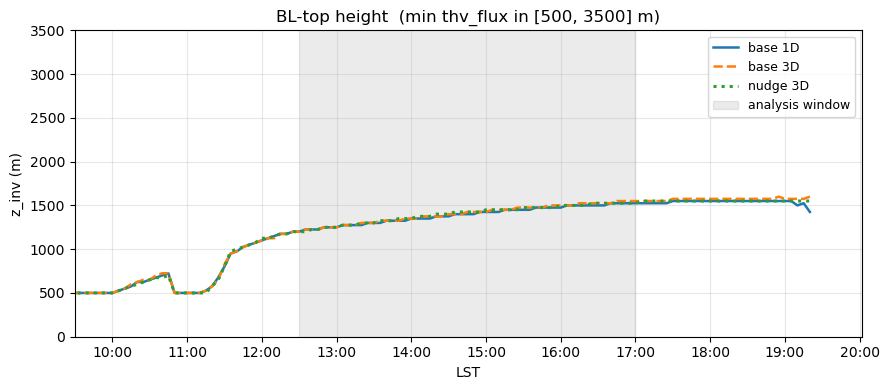

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

for label, s in stats.items():
    t  = pd.DatetimeIndex(s["t_local"])
    nt = min(len(t), z_inv[label].shape[0])
    ax.plot(t[:nt], z_inv[label][:nt], label=label, **STYLE[label])

ax.set_xlim(pd.Timestamp("2005-07-24 9:30"), None)
ax.axvspan(T0, T1, alpha=0.08, color="k", label="analysis window")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_ylabel("z_inv (m)")
ax.set_ylim(0, 3500)
ax.set_xlabel("LST")
ax.set_title("BL-top height  (min thv_flux in [500, 3500] m)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. thl and qt difference from base 1D

Shows how well the nudge constrained the 3D BL state.
If nudge 3D ≈ 0, the nudge worked and any LWP difference is a direct 3D RT effect.

## 6. Profile evolution: θ_l, q_t, q_l within the cloudy window

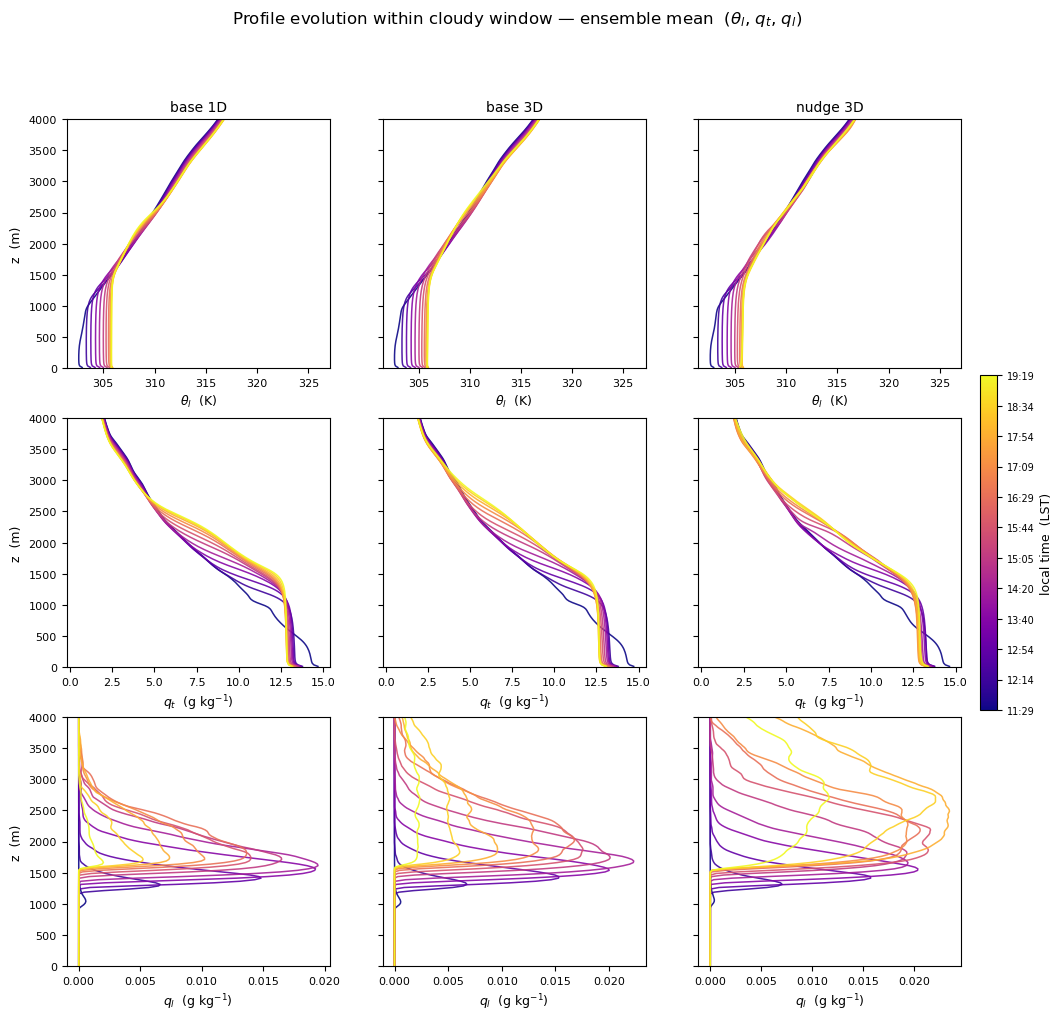

Saved profiles_thl_qt_ql_evolution.pdf


In [8]:
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

# ── Time / cloudy mask derived from stats ─────────────────────────────────────
t_local = stats["base 1D"]["t_local"]
t_pd    = pd.DatetimeIndex(t_local)
t_sec   = (t_pd - t_pd[0]).total_seconds().values

nt = min(
    len(stats["base 1D"]["t_local"]),
    len(stats["base 3D"]["t_local"]),
    len(stats["nudge 3D"]["t_local"]),
)

lwp_1d_ts = stats["base 1D"]["qlqi_path"][:nt] * 1e3
lwp_rt_ts = stats["base 3D"]["qlqi_path"][:nt] * 1e3
lwp_nd_ts = stats["nudge 3D"]["qlqi_path"][:nt] * 1e3
cloudy_mask = (lwp_1d_ts > 0.1) | (lwp_rt_ts > 0.1) | (lwp_nd_ts > 0.1)

# ── Sample indices within cloudy window (evenly spaced) ───────────────────────
win_idx   = np.where(cloudy_mask)[0]
n_samples = min(12, len(win_idx))
samp_idx  = win_idx[np.round(np.linspace(0, len(win_idx) - 1, n_samples)).astype(int)]

t_win  = t_sec[samp_idx]
t_norm = (t_win - t_win[0]) / max(t_win[-1] - t_win[0], 1.0)

cmap  = plt.cm.plasma
cnorm = mcolors.Normalize(vmin=0, vmax=1)

def _fmt_t(ts):
    try:
        return pd.Timestamp(ts).strftime("%H:%M")
    except Exception:
        return str(ts)[-8:-3]

# ── Layout: 3 rows (thl, qt, ql) × 3 cols (base 1D, base 3D, nudge 3D) ───────
run_labels = ["base 1D", "base 3D", "nudge 3D"]
var_info = [
    (r"$\theta_l$  (K)",        "thl", 1.0),
    (r"$q_t$  (g kg$^{-1}$)",  "qt",  1e3),
    (r"$q_l$  (g kg$^{-1}$)",  "ql",  1e3),
]

z_max = min(4000.0, float(z.max()))

fig, axes = plt.subplots(3, 3, figsize=(12, 11), sharey=True)

for row, (xlabel, var_key, scale) in enumerate(var_info):
    for col, run_label in enumerate(run_labels):
        ax   = axes[row, col]
        data = stats[run_label][var_key][:nt] * scale
        for k, ti in enumerate(samp_idx):
            c = cmap(cnorm(t_norm[k]))
            ax.plot(data[ti], z, color=c, lw=1.1, alpha=0.9)
        ax.set_ylim(0, z_max)
        ax.axhline(0, color="0.8", lw=0.4)
        if col == 0:
            ax.set_ylabel("z  (m)", fontsize=9)
        ax.set_xlabel(xlabel, fontsize=9)
        if row == 0:
            ax.set_title(run_label, fontsize=10)
        ax.tick_params(labelsize=8)

sm = ScalarMappable(cmap=cmap, norm=cnorm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.018, pad=0.02)
cbar.set_label("local time  (LST)", fontsize=9)
tick_pos  = np.linspace(0, 1, n_samples)
tick_labs = [_fmt_t(t_local[samp_idx[k]]) for k in range(n_samples)]
cbar.set_ticks(tick_pos)
cbar.set_ticklabels(tick_labs, fontsize=7)

fig.suptitle(
    r"Profile evolution within cloudy window — ensemble mean  ($\theta_l$, $q_t$, $q_l$)",
    fontsize=12,
)

plt.savefig("profiles_thl_qt_ql_evolution.pdf", bbox_inches="tight")
plt.show()
print("Saved profiles_thl_qt_ql_evolution.pdf")

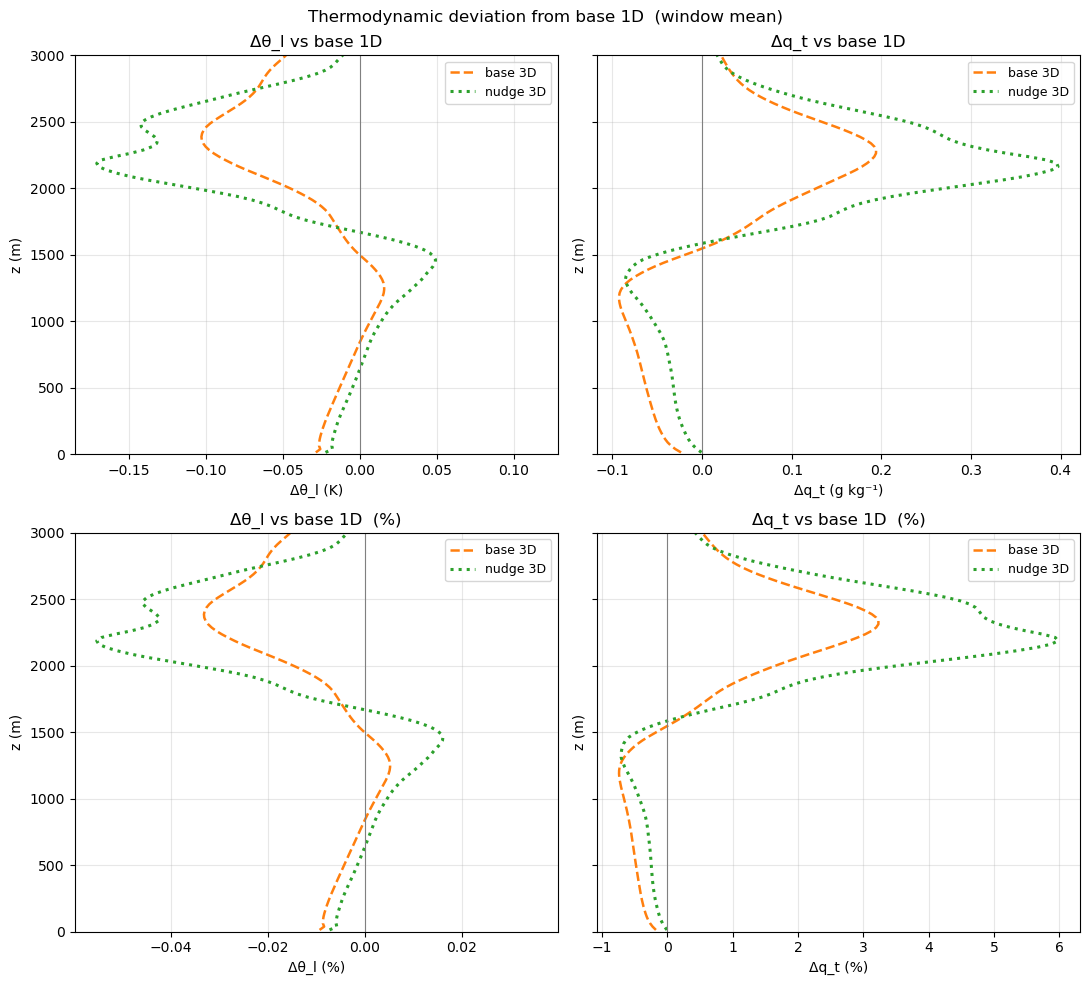

In [6]:
ref_thl = window_mean_profile(stats["base 1D"], "thl")
ref_qt  = window_mean_profile(stats["base 1D"], "qt") * 1e3

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharey=True)

for label in ("base 3D", "nudge 3D"):
    s  = stats[label]
    st = STYLE[label]
    d_thl = window_mean_profile(s, "thl") - ref_thl
    d_qt  = window_mean_profile(s, "qt") * 1e3 - ref_qt
    p_thl = d_thl / np.abs(ref_thl) * 100
    p_qt  = d_qt  / np.abs(ref_qt)  * 100
    axes[0, 0].plot(d_thl, z, label=label, **st)
    axes[0, 1].plot(d_qt,  z, label=label, **st)
    axes[1, 0].plot(p_thl, z, label=label, **st)
    axes[1, 1].plot(p_qt,  z, label=label, **st)

row_labels = [("Δθ_l (K)", "Δq_t (g kg⁻¹)"), ("Δθ_l (%)", "Δq_t (%)")]
for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        ax.axvline(0, color="0.5", lw=0.8, ls="-")
        ax.set_ylabel("z (m)")
        ax.set_ylim(0, 3000)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_xlabel(row_labels[row][col])

axes[0, 0].set_title("Δθ_l vs base 1D")
axes[0, 1].set_title("Δq_t vs base 1D")
axes[1, 0].set_title("Δθ_l vs base 1D  (%)")
axes[1, 1].set_title("Δq_t vs base 1D  (%)")
plt.suptitle("Thermodynamic deviation from base 1D  (window mean)")
plt.tight_layout()
plt.show()